Model Evaluation on Test Set:
Brier Score: 0.1691
ROC AUC Score: 0.8129

Predicted Diabetes Risk for user input: 15.67%


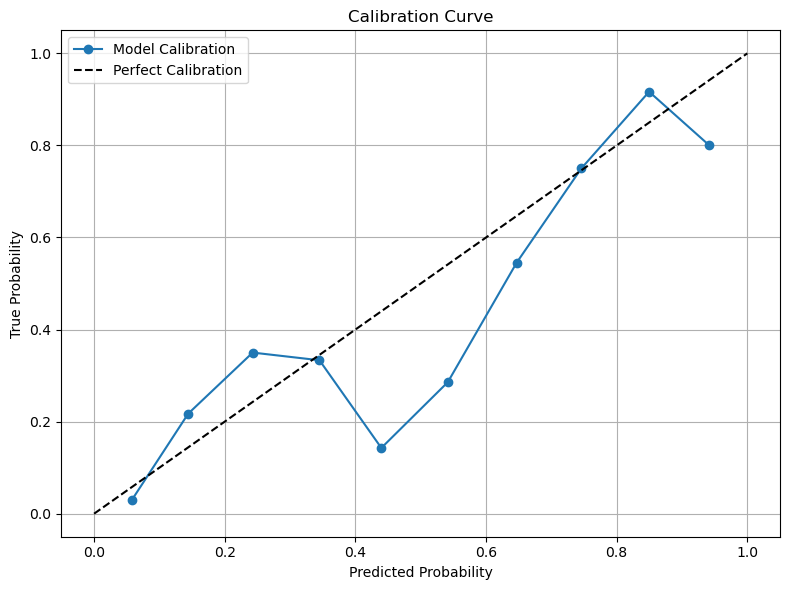

In [24]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss, roc_auc_score
import matplotlib.pyplot as plt

# Function to map user input to PIMA dataset features
def map_user_to_pima(user_input):
    height_m = user_input['Height'] / 100  # cm to meters
    bmi = user_input['Weight'] / (height_m ** 2)

    # Approximate values for features not directly in user input
    blood_pressure = 140 if user_input['BloodPressure'] == 'Yes' else 80
    pedigree = 1.5 if user_input['FamilyHistory'] == 'Yes' else 0.3

    # Set some default values or proxy values
    glucose = 120  # average glucose level
    pregnancies = 0  # default if unknown, can be changed

    skin_thickness = 20 if user_input['Cholesterol'] == 'Yes' else 10
    insulin = 100 if user_input['Cholesterol'] == 'Yes' else 50

    return {
        'Pregnancies': pregnancies,
        'Glucose': glucose,
        'BloodPressure': blood_pressure,
        'SkinThickness': skin_thickness,
        'Insulin': insulin,
        'BMI': bmi,
        'DiabetesPedigreeFunction': pedigree,
        'Age': user_input['Age']
    }

# Your example user input
user_input = {
    'Gender': 'Male',
    'Age': 45,
    'Height': 175,     # cm
    'Weight': 80,      # kg
    'Waist': 38,       # inches (not used here, but can be added in extended model)
    'Diet': 3,         # meals per day (not used here)
    'TypeOfDiabetes': 'Type 2',  # Not used in this prediction
    'HowLongDiabetiesHave': 2,   # Not used in this prediction
    'FamilyHistory': 'Yes',
    'BloodPressure': 'Yes',
    'Cholesterol': 'Yes',
    'ThirstHunger': 'Yes',      # Not used here
    'Fatigue': 'Yes',           # Not used here
    'Urination': 'No',          # Not used here
    'VisionChanges': 'Yes'      # Not used here
}

# Map user input to model features
mapped_features = map_user_to_pima(user_input)

# Load PIMA dataset
url = "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv"
df = pd.read_csv(url)

# Features and target for training
X = df[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
        'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']]
y = df['Outcome']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train logistic regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict probabilities for the test set
y_prob_test = model.predict_proba(X_test)[:, 1]

# Evaluate Brier score and ROC AUC
brier = brier_score_loss(y_test, y_prob_test)
roc_auc = roc_auc_score(y_test, y_prob_test)

print(f"Model Evaluation on Test Set:")
print(f"Brier Score: {brier:.4f}")
print(f"ROC AUC Score: {roc_auc:.4f}")

# Predict diabetes risk for your user input
user_df = pd.DataFrame([mapped_features])
user_risk = model.predict_proba(user_df)[:, 1][0]
print(f"\nPredicted Diabetes Risk for user input: {user_risk:.2%}")

# Plot calibration curve for test set
prob_true, prob_pred = calibration_curve(y_test, y_prob_test, n_bins=10)

plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', label='Model Calibration')
plt.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration')
plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.title("Calibration Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
